In [297]:
import numpy as np
from rolland.database.rail.db_rail import UIC60


from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points

In [298]:
rail_geometry = UIC60.rl_geo
length = 5
mesh_size = 0.05
rail_geometry = interpolate_contour_2d(rail_geometry, 25)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=mesh_size,
                                              L=length  #146.0
                                              )

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
print(f'mean area = {A.mean()}')
projected_area = calculate_projected_area(A, norm, 1)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
I

## First Simulation that we need: validation with Wagner simulation

1. Fine simulation with 2.5m, 5m, 7.5m and 10m radius
2. Compare the results with the Wagner simulation data

In [299]:
from rolland import SimplePeriodicBallastedSingleRailTrack, DiscrPad, Sleeper, Ballast, PMLRailDampVertic, GaussianImpulse

from rail_deflection import rail_deflection_rolland

import scipy as sp

track = SimplePeriodicBallastedSingleRailTrack(
    rail=UIC60,  # Standard UIC60 rail profile
    pad=DiscrPad(
        sp=[4.5e8, 0],  # Stiffness properties [N/m]
        dp=[33000, 0]  # Damping properties [Ns/m]
    ),
    sleeper=Sleeper(ms=150),  # Sleeper mass [kg]
    ballast=Ballast(
        sb=[105e6, 0],  # Ballast stiffness [N/m]
        db=[75000, 0]  # Ballast damping [Ns/m]
    ),
    num_mount=243,  # Number of discrete mounting positions
    distance=0.6  # Distance between sleepers [m]
)


boundary = PMLRailDampVertic(l_bound=33.0)  # 33.0 m boundary domain

excitation = GaussianImpulse(x_excit=71.7)

resp_func, dict_func = rail_deflection_rolland(track, boundary, excitation)

nt_rolland = dict_func['nt']
dt_rolland = dict_func['dt']
nx_rolland = dict_func['nx']
dx_rolland = dict_func['dx']

excitation_point = 71.7
simulation_z_start_rolland = excitation_point - length / 2 #starting point from where we consider deflections
simulation_z_end_rolland = 71.7 + length / 2
nx_simulation_rolland = int(round(length / dx_rolland)) + 1 #number of x points for which we consider the deflection
centre_sim = centre.copy()
centre_sim[:, 2] = centre_sim[:, 2] + simulation_z_start_rolland #centres in rolland axis
start_index_rolland = int(round(simulation_z_start_rolland / (2 * dx_rolland)))
end_index_rolland = int(start_index_rolland + nx_simulation_rolland)

print(f'excitation point = {excitation_point}'
      f'simulation_start_m = {simulation_z_start_rolland}'
      f'simulation z_start_rolland_index = {start_index_rolland}'
      f'simulation z_end_rolland_index = {end_index_rolland}'
      f'nx_simulation_rolland = {nx_simulation_rolland}'
      f'simulation_dx = {dx_rolland}')

print(f"ROLLAND RESP SHAPE = {dict_func['deflection'].shape}")
rail_deflection_xt = dict_func['deflection'][0::2, :].copy()
rolland_resp_sim = rail_deflection_xt[
    start_index_rolland:end_index_rolland,
    :
]
print(rolland_resp_sim.shape)

f_sim_axis = sp.fft.rfftfreq(rolland_resp_sim.shape[1], dt_rolland)
#f_sim_axis = dict_func['frequencies']
#to handle the simulations as fast as we can, we are going to look at a given frequency spectrum
f_min = 0
f_max = 3000
frequency_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)

excitation point = 71.7simulation_start_m = 69.2simulation z_start_rolland_index = 634simulation z_end_rolland_index = 727nx_simulation_rolland = 93simulation_dx = 0.05454545454545454
ROLLAND RESP SHAPE = (5326, 20001)
(93, 20001)


In [300]:
print(f'total_nx. {nx_rolland}')

total_nx. 2663


## We can do this in frequency domain and time domain, but let's start with frequency domain first

In [301]:
# FFT muss ueber die Zeitachse laufen (axis=1), da rolland_resp_sim die Form (x, t) hat.
u_rolland_fd = sp.fft.rfft(rolland_resp_sim, norm='forward', axis=1)
print(f'u_rolland_fd max = {u_rolland_fd.max()}'
      f'u_rolland_fd shape = {u_rolland_fd.shape}')

u_rolland_fd = u_rolland_fd[:, frequency_mask]
print(u_rolland_fd.max())
print(u_rolland_fd.shape)
omega = 2 * np.pi * f_sim_axis[frequency_mask]
print(f_sim_axis[frequency_mask])
v_rolland_fd = (1j * omega[None, :]) * u_rolland_fd
print(v_rolland_fd.max())
print(v_rolland_fd.shape)
nx_rolland_in_simulation = v_rolland_fd.shape[0]
x_axis_rolland_in_sim = np.arange(nx_rolland_in_simulation) * (2 *  dx_rolland)

print(f'axis_length = {x_axis_rolland_in_sim.shape}'
      f'v shape = {v_rolland_fd.shape}'
      f'centre shape = {centre.shape}')
rolland_triangle_v_fd = assign_v_to_points(
    x_axis_rolland_in_sim,
    v_rolland_fd,
    centre)

u_rolland_fd max = (2.46909184997389e-07-2.202605109949999e-08j)u_rolland_fd shape = (93, 10001)
(2.46909184997389e-07-2.202605109949999e-08j)
(93, 1201)
[0.00000000e+00 2.49987501e+00 4.99975001e+00 ... 2.99485026e+03
 2.99735013e+03 2.99985001e+03]
(0.001326452780756046-0.0011702937842208365j)
(93, 1201)
axis_length = (93,)v shape = (93, 1201)centre shape = (9670, 3)


In [302]:
from utils import run_simulation_semi_circle
from frequency_domain import monopole_multi_fa__calcf__outf

semi_circle_centre = np.array((-0.71, -0.08, excitation_point))
P_25 = run_simulation_semi_circle(
    circle_centre=semi_circle_centre,
    circle_radius=2.5,
    number_of_points=10,
    simulation_function=monopole_multi_fa__calcf__outf,
    V_fd=rolland_triangle_v_fd,
    freqs=f_sim_axis[frequency_mask],
    X=centre_sim,
    A=projected_area[:, None]
)

In [303]:
wagner_simulation_data = np.genfromtxt('Default Dataset.csv', delimiter=';')

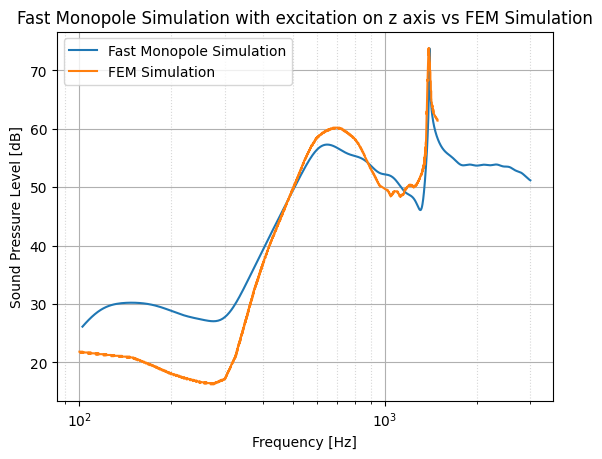

In [304]:
from matplotlib import pyplot as plt

p0 = 2e-5
P_db = 20 * np.log10((np.abs(P_25) + p0) / p0)
plt_mask = (f_sim_axis[frequency_mask] >= 100) & (f_sim_axis[frequency_mask] <= f_max)
plt_f_axis = f_sim_axis[frequency_mask][plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db, label='Fast Monopole Simulation')
plt.plot(wagner_simulation_data[:, 0], wagner_simulation_data[:, 1], label="FEM Simulation")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Pressure Level [dB]')
plt.legend()
plt.xscale('log')
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.title('Fast Monopole Simulation with excitation on z axis vs FEM Simulation')
plt.show()

In [305]:
nx_rolland * dx_rolland

145.25454545454545